# Day 4 — Feature Engineering & Hyperparameter Tuning

Engineering new features from the Titanic dataset, tuning a Random Forest with GridSearchCV, and honestly evaluating whether the engineered features and the tuning actually helped.

## Loading and Initial Inspection
Load the dataset and take a first look at its shape, structure, and class balance before engineering anything.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
print (df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The dataset has 891 rows and 12 columns, covering each passenger's class, name, sex, age, family aboard, fare, and survival outcome.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


.info() shows Age, Cabin, and Embarked have fewer non-null entries than the rest — confirmed exactly below.

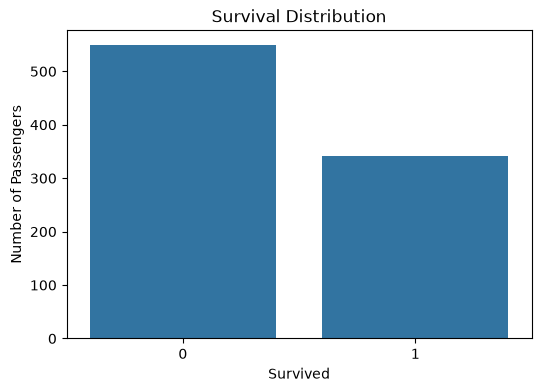

In [4]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

The count plot shows more passengers did not survive than did — a moderate class imbalance, which is why F1 (not accuracy) is used as the scoring metric throughout this notebook.

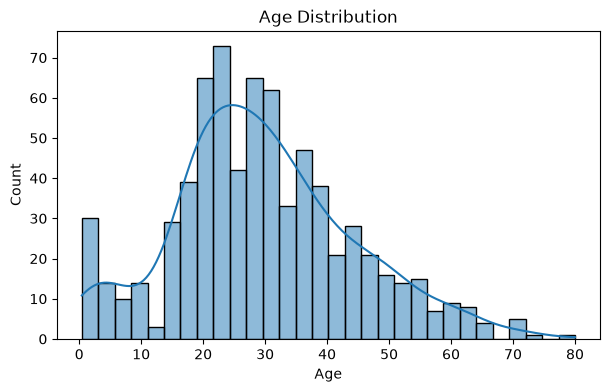

In [5]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

The age distribution is right-skewed with a concentration in the 20s–30s and a long tail toward older ages, plus a visible gap where Age is missing for a large share of passengers.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

.isnull().sum() confirms the exact gaps: Age is missing 177 values, Cabin is missing 687 (the large majority), and Embarked is missing 2.

In [7]:
df = df.drop(columns=["PassengerId", "Cabin"])

PassengerId (just a row identifier) and Cabin (missing for over 77% of passengers, too sparse to use reliably) are dropped.

## Step 1 — Engineering Two New Features

### 1. FamilySize

FamilySize = SibSp + Parch + 1

This feature represents the total number of people in a passenger's family group, including the passenger.

**Justification:** SibSp and Parch describe different types of family relationships. Combining them into a single FamilySize feature provides a more direct representation of the overall family group size, which may contain useful information about survival.

### 2. IsAlone

IsAlone = 1 if FamilySize == 1, otherwise 0.

This binary feature indicates whether a passenger was traveling alone or with at least one family member.

**Justification:** Traveling alone may represent a different survival pattern from traveling with family members. This feature allows the model to capture that distinction directly rather than relying only on the numerical FamilySize value.

Both features will be evaluated experimentally to determine whether they actually improve model performance.

In [8]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

Both columns are added directly to df, ready to be used as model features.

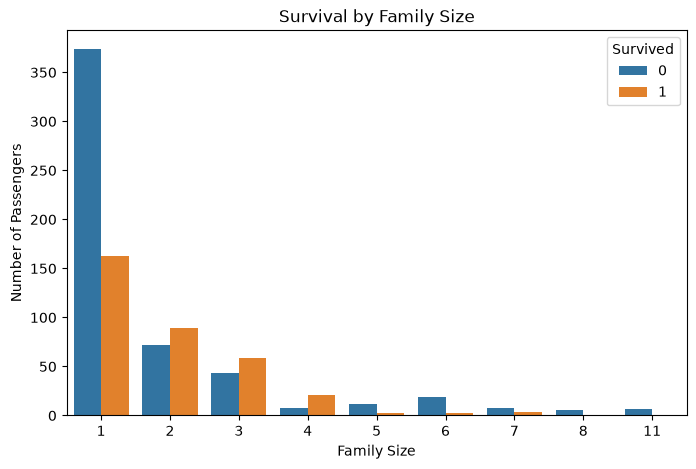

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="FamilySize",
    hue="Survived"
)

plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.show()

The grouped count plot shows the distribution of survivors and non-survivors across different family sizes. It provides an initial visual indication that survival outcomes vary across family groups, particularly between passengers traveling alone, passengers in small-to-medium families, and passengers in larger families.

This observation provides motivation for testing FamilySize as an engineered feature, while its actual contribution to model performance will be evaluated later using cross-validation.

In [10]:
X = df.drop(["Survived" ,"Name" , "Ticket"], axis =1 )
y = df["Survived"]

X holds every column except Survived and Ticket (a free-text code with no generalizable signal); y holds the target.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (712, 9)
X_test: (179, 9)


An 80/20 train/test split (712/179 rows) is performed with random_state=42 and stratify=y to preserve the class balance.

In [12]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

categorical_features = [
    "Sex",
    "Embarked"
]


The features are divided into two groups based on their data type. Numeric features include Pclass, Age, SibSp, Parch, Fare, FamilySize, and IsAlone, while categorical features include Sex and Embarked.

This separation allows each group to receive the appropriate preprocessing steps before being passed to the Random Forest model.

In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

A ColumnTransformer bundles two sub-pipelines: numeric columns get median-imputed then scaled, categorical columns get most-frequent-imputed then one-hot encoded. Wrapping preprocessing in a pipeline like this ensures it's refit correctly and leak-free inside every cross-validation fold below.

In [14]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

The full pipeline chains the preprocessor directly into a RandomForestClassifier, so a single .fit() call handles preprocessing and modeling together.

In [15]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

A shared 5-fold KFold (shuffled, random_state=42) is defined once, so it can be reused identically across every cross-validation call in this notebook — keeping every comparison that follows fair and consistent.

## Establishing a Baseline — Untuned Random Forest

Before tuning the model, we establish a baseline using the default RandomForestClassifier settings.

The complete preprocessing and modeling pipeline is evaluated using 5-fold cross-validation with F1 score. This baseline provides a reference point for measuring whether hyperparameter tuning improves the model's performance.

In [16]:
baseline_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="f1"
)

print("Baseline F1 scores:", baseline_scores)
print("Baseline Mean F1:", baseline_scores.mean())
print("Baseline Std:", baseline_scores.std())

Baseline F1 scores: [0.72222222 0.68888889 0.72881356 0.72566372 0.76190476]
Baseline Mean F1: 0.7254986298304132
Baseline Std: 0.023183746213595726


**Baseline Mean F1: 0.7255 ± 0.0232**

The five cross-validation folds produced F1 scores of **0.722, 0.689, 0.729, 0.726, and 0.762**.

This represents the performance of the untuned Random Forest using the default hyperparameters and both engineered features. It will serve as the reference point for evaluating the effect of hyperparameter tuning.

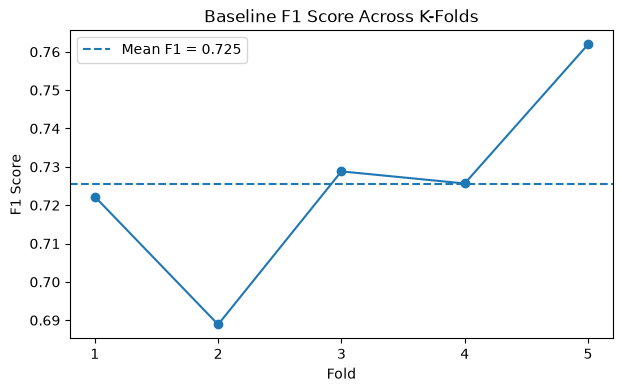

In [17]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, 6),
    baseline_scores,
    marker="o"
)

plt.axhline(
    baseline_scores.mean(),
    linestyle="--",
    label=f"Mean F1 = {baseline_scores.mean():.3f}"
)

plt.title("Baseline F1 Score Across K-Folds")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.xticks(range(1, 6))
plt.legend()

plt.show()

The line plot shows the same 5 fold scores clustered fairly close to the mean line, with fold 2 (0.689) as the weakest and fold 5 (0.762) as the strongest.

## Step 2 — Defining the Hyperparameter Grid

## Step 3 — Running GridSearchCV
Define a grid over three Random Forest hyperparameters (n_estimators, max_depth, min_samples_split) and run GridSearchCV with the same 5-fold split to find the best combination — 3 × 3 × 2 = 18 combinations × 5 folds = 90 model fits.

In [18]:

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}



grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best CV F1:
0.7497454231162097


**Best Parameters:** max_depth=None, min_samples_split=5, n_estimators=300.

**Best Cross-Validated F1: 0.7497**

The tuned model achieved a higher mean cross-validated F1 score than the untuned baseline (**0.7255 → 0.7497**). This improvement was obtained by systematically searching the predefined hyperparameter combinations while keeping the same Random Forest model, preprocessing pipeline, and engineered features.

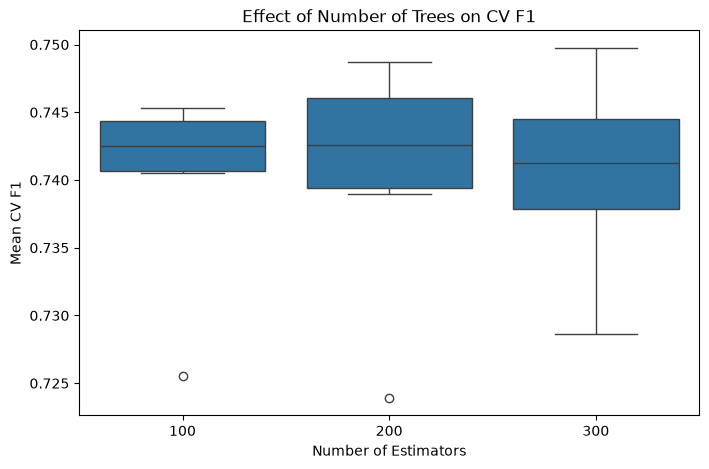

In [19]:
results = pd.DataFrame(grid_search.cv_results_)



plt.figure(figsize=(8, 5))

sns.boxplot(
    data=results,
    x="param_model__n_estimators",
    y="mean_test_score"
)

plt.title("Effect of Number of Trees on CV F1")
plt.xlabel("Number of Estimators")
plt.ylabel("Mean CV F1")

plt.show()

The boxplot shows the distribution of cross-validated F1 scores for the different values of n_estimators tested by GridSearchCV.

The scores across 100, 200, and 300 trees are relatively close, suggesting that the number of trees alone did not produce a large difference in performance. However, GridSearchCV evaluates hyperparameters in combination, so the individual contribution of n_estimators, max_depth, and min_samples_split cannot be determined from this plot alone.

The best overall combination was n_estimators=300, max_depth=None, and min_samples_split=5.

## Step 4 — Tuned Model vs. Untuned Baseline
Fit the best model from the grid search, evaluate it once on the held-out test set, and compare it back to the untuned baseline's cross-validated score.

In [20]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)


test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test F1 Score:", test_f1)
print(classification_report(y_test, y_pred))


Test Accuracy: 0.8100558659217877
Test F1 Score: 0.734375
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



**Held-out Test Set Results**

The tuned Random Forest achieved an **accuracy of 0.810** and an **F1 score of 0.734** on the held-out test set. For the Survived class, the model achieved **0.80 precision** and **0.68 recall**.

The test set was kept completely separate from the hyperparameter tuning process. GridSearchCV selected the best hyperparameters using only the training data through 5-fold cross-validation, where the best mean F1 score was **0.7497**.

This provides a more reliable estimate of how the final tuned model performs on unseen data.

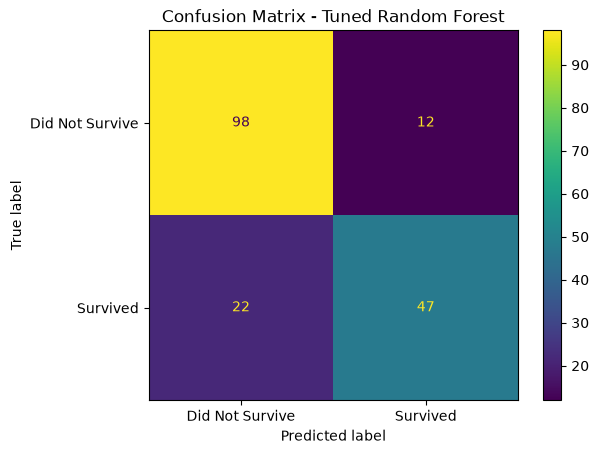

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

The confusion matrix shows the same story numerically: the model is noticeably better at correctly identifying passengers who did *not* survive than those who did, missing a meaningful share of actual survivors (the lower recall for class 1).

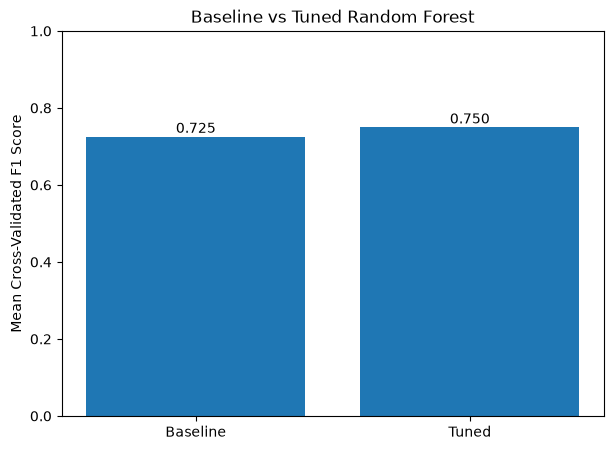

In [22]:
baseline_mean = baseline_scores.mean()
tuned_mean = grid_search.best_score_

models = ["Baseline", "Tuned"]
scores = [baseline_mean, tuned_mean]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, scores)

plt.title("Baseline vs Tuned Random Forest")
plt.ylabel("Mean Cross-Validated F1 Score")
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.01,
        f"{score:.3f}",
        ha="center"
    )

plt.show()

**Baseline vs Tuned, side by side: 0.725 → 0.750 mean CV F1** — roughly a 2.5-point improvement from hyperparameter tuning alone, using the exact same features and the exact same 5-fold split for both, so the comparison is fair.

## Step 5 — Evaluating Engineered Features

To determine whether the engineered features contributed to model performance, we re-run 5-fold cross-validation using the best hyperparameters found by GridSearchCV:

- n_estimators = 300
- max_depth = None
- min_samples_split = 5

We compare four feature sets: both engineered features, FamilySize without IsAlone, IsAlone without FamilySize, and the original features without either engineered feature.

This feature ablation analysis helps determine whether FamilySize and IsAlone provide useful information beyond the original Titanic features.

The GridSearchCV results are also examined to understand the best hyperparameter combination. Since the parameters were tuned jointly, their individual effects are interpreted cautiously rather than assuming that one parameter alone caused the improvement.

In [23]:
X_no_engineered = df.drop( ["Survived", "Ticket", "FamilySize", "IsAlone"], axis =1)

y = df["Survived"]

Rebuild X/y and a fresh train/test split using only the original columns — no FamilySize, no IsAlone — to establish a true "no engineered features" comparison point.

In [24]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_no_engineered,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
numeric_base = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_base = [
    "Sex",
    "Embarked"
]

A matching preprocessing pipeline is built for the non-engineered feature set.

In [26]:
numeric_pipeline_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_base = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [27]:
preprocessor_base = ColumnTransformer([
    ("num", numeric_pipeline_base, numeric_base),
    ("cat", categorical_pipeline_base, categorical_base)
])

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ))
])

In [28]:
baseline_feature_scores = cross_val_score(
    baseline_pipeline,
    X_train_base,
    y_train_base,
    cv=kf,
    scoring="f1"
)

print("Without Engineered Features:")
print(baseline_feature_scores)
print("Mean F1:", baseline_feature_scores.mean())

Without Engineered Features:
[0.72897196 0.69662921 0.75213675 0.76363636 0.81553398]
Mean F1: 0.7513816544911218


### Without Engineered Features

**Mean CV F1: 0.7514**

The five cross-validation folds produced F1 scores of **0.729, 0.697, 0.752, 0.764, and 0.816**.

This experiment uses the same tuned Random Forest hyperparameters selected by GridSearchCV (n_estimators=300, max_depth=None, and min_samples_split=5), but removes both FamilySize and IsAlone.

Interestingly, the model achieved a slightly higher mean F1 (**0.7514**) than the fully engineered version (**0.7497**). This indicates that the engineered features did not improve the overall cross-validated performance in this experiment.

In [29]:
X_no_family = df.drop(
    columns=["Survived", "Ticket", "FamilySize"]
)

X_train_nf, X_test_nf, y_train_nf, y_test_nf = train_test_split(
    X_no_family,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Build a version of the pipeline with IsAlone kept but FamilySize removed, to isolate FamilySize's individual contribution.

In [30]:
X_no_family = df.drop(
    columns=["Survived", "Ticket", "FamilySize"]
)

X_train_nf, X_test_nf, y_train_nf, y_test_nf = train_test_split(
    X_no_family,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
numeric_nf = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "IsAlone"
]

preprocessor_nf = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_nf),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), ["Sex", "Embarked"])
])

pipeline_nf = Pipeline([
    ("preprocessor", preprocessor_nf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ))
])
score_no_family = cross_val_score(
    pipeline_nf,
    X_train_nf,
    y_train_nf,
    cv=kf,
    scoring="f1"
).mean()

print("Mean F1 without FamilySize:", score_no_family)

Mean F1 without FamilySize: 0.7410226488487359


### Without FamilySize

**Mean CV F1: 0.7410**

In this experiment, FamilySize was removed while IsAlone was kept. The mean cross-validated F1 score decreased to **0.7410**, which was the lowest score among the four feature configurations tested.

Compared with the fully engineered version (**0.7497**), removing FamilySize reduced the mean F1 by approximately **0.0087**. This suggests that FamilySize provided useful information when combined with the other features, although it did not lead to the best overall result when compared with the model without engineered features.

In [32]:
X_no_alone = df.drop(
    columns=["Survived", "Ticket", "IsAlone"]
)

X_train_na, X_test_na, y_train_na, y_test_na = train_test_split(
    X_no_alone,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_na = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

preprocessor_na = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_na),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), ["Sex", "Embarked"])
])

pipeline_na = Pipeline([
    ("preprocessor", preprocessor_na),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ))
])

score_no_alone = cross_val_score(
    pipeline_na,
    X_train_na,
    y_train_na,
    cv=kf,
    scoring="f1"
).mean()

print("Mean F1 without IsAlone:", score_no_alone)

Mean F1 without IsAlone: 0.7511582369719656


### Without IsAlone

In this experiment, IsAlone is removed while FamilySize is retained. This allows us to evaluate whether IsAlone provides additional predictive information beyond the other features, including FamilySize.

### Results Without IsAlone

**Mean CV F1: 0.7512**

When IsAlone was removed while keeping FamilySize, the model achieved a mean cross-validated F1 score of **0.7512**.

This is slightly higher than the fully engineered version (**0.7497**) and very close to the model without either engineered feature (**0.7514**). This suggests that IsAlone provided little additional predictive value in this experiment.

In [33]:
feature_results = pd.DataFrame({
    "Experiment": [
        "Both Features",
        "Without FamilySize",
        "Without IsAlone",
        "Without Both"
    ],
    "Mean CV F1": [
        grid_search.best_score_,
        score_no_family,
        score_no_alone,
        baseline_feature_scores.mean()
    ]
})

feature_results

,Experiment,Mean CV F1
0,Both Features,0.749745
1,Without FamilySize,0.741023
2,Without IsAlone,0.751158
3,Without Both,0.751382


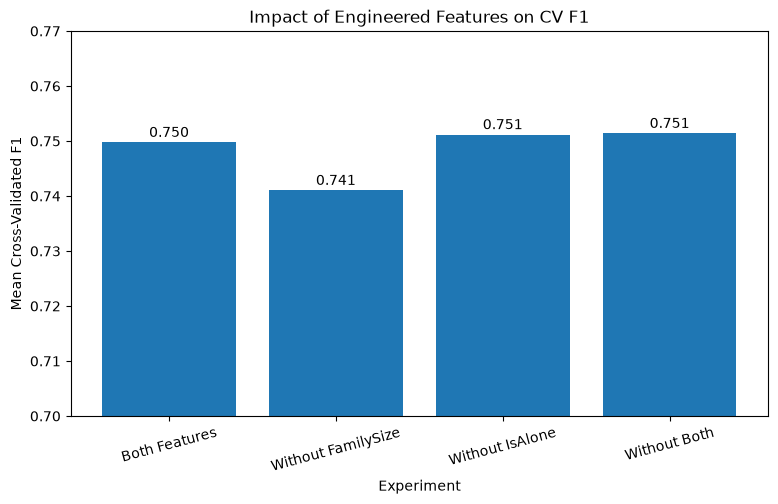

In [34]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    feature_results["Experiment"],
    feature_results["Mean CV F1"]
)

plt.title("Impact of Engineered Features on CV F1")
plt.xlabel("Experiment")
plt.ylabel("Mean Cross-Validated F1")
plt.ylim(0.70, 0.77)
plt.xticks(rotation=15)

for bar, score in zip(bars, feature_results["Mean CV F1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.001,
        f"{score:.3f}",
        ha="center"
    )

plt.show()

### Feature Engineering Results

| Experiment | Mean CV F1 |
|---|---:|
| Both Features | 0.7497 |
| Without FamilySize | 0.7410 |
| Without IsAlone | 0.7512 |
| Without Both | 0.7514 |

### Honest Conclusion

The ablation results show that neither engineered feature produced an overall improvement compared with the original feature set.

The highest mean CV F1 was obtained **without either engineered feature (0.7514)**, while removing only IsAlone produced a very similar score of **0.7512**. Keeping both engineered features resulted in **0.7497**, and keeping only IsAlone while removing FamilySize produced the lowest score of **0.7410**.

These results suggest that IsAlone provided little additional predictive value, possibly because it contains information that is already represented by SibSp and Parch. FamilySize showed some useful signal because removing it while keeping IsAlone caused the F1 score to decrease, but it still did not improve the overall model compared with using the original features alone.

This demonstrates an important practical lesson: **feature engineering should be validated experimentally rather than assumed to improve model performance.**

### Hyperparameter Tuning Conclusion

Hyperparameter tuning clearly improved the model's mean cross-validated F1 score:

**Baseline: 0.7255 → Tuned: 0.7497**

This represents an absolute improvement of approximately **0.0242 (2.42 percentage points)**.

The best combination found by GridSearchCV was:

- n_estimators = 300
- max_depth = None
- min_samples_split = 5

The n_estimators comparison showed relatively small differences across 100, 200, and 300 trees. However, because GridSearchCV evaluates the hyperparameters jointly, the individual contribution of max_depth and min_samples_split cannot be determined conclusively from the current experiments.

Therefore, the safest conclusion is that **the combination of hyperparameters selected by GridSearchCV improved performance**, rather than claiming that one specific hyperparameter was solely responsible for the improvement.